In [31]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
import pickle
from tqdm import tqdm

plt.style.use(['science','notebook'])

In [32]:
def compute_IGs(imbalances):    
    n_indep_realizations = imbalances.shape[0]
    n_eps = imbalances.shape[1]
    
    IGs_vs_alpha = 100*(imbalances[:,:,0,np.newaxis]-imbalances) / imbalances[:,:,0,np.newaxis]
    alphas_max = np.argmax(IGs_vs_alpha.mean(axis=0), axis=-1)

    IGs = IGs_vs_alpha.mean(axis=0)[np.arange(n_eps),alphas_max]
    errors = IGs_vs_alpha.std(axis=0)[np.arange(n_eps),alphas_max] / np.sqrt(n_indep_realizations)
    
    return IGs, errors

In [33]:
def compute_IGs_cond(imbs_no_cause, imbs_with_cause, alphas_cause, alphas_cond):    
    assert imbs_no_cause.shape[0] == imbs_with_cause.shape[0], "Error: shape mismatch!"
    assert imbs_no_cause.shape[1] == len(alphas_cond), "Error: shape mismatch!"
    assert imbs_with_cause.shape[1] == len(alphas_cause)*len(alphas_cond), "Error: shape mismatch!"

    n_indep_realizations = imbs_no_cause.shape[0]

    #IGs_vs_alpha = 100*(1. - imbs_with_cause.reshape(n_indep_realizations,len(alphas_cause),len(alphas_cond)) / imbs_no_cause[:,np.newaxis,:]) 
    #IGs_vs_alpha = IGs_vs_alpha.reshape((n_indep_realizations, len(alphas_cause)*len(alphas_cond)))

    IGs_vs_alpha = 100*(1. - imbs_with_cause.reshape(n_indep_realizations,len(alphas_cause),len(alphas_cond)).min(axis=1) / imbs_no_cause.min(axis=1)[:,np.newaxis]) 
    alpha_max = np.argmax(IGs_vs_alpha.mean(axis=0), axis=-1)

    IGs = IGs_vs_alpha.mean(axis=0)[alpha_max]
    errors = IGs_vs_alpha.std(axis=0)[alpha_max] / np.sqrt(n_indep_realizations)

    #IGs_all = 100*(1. - imbs_with_cause.min(axis=1) / imbs_no_cause.min(axis=1))
    #IGs = IGs_all.mean()
    #errors = IGs_all.std() / np.sqrt(n_indep_realizations)
    
    return IGs, errors

In [34]:
colors = ["#00BBF9", "#CC2836", "#F3A712","#3eb690","#A05496","#114b5f"]
markers = ['o-','s-','^-']

In [35]:
seeds = np.arange(20)
epsilons = np.linspace(0.,0.25,30)
alphas = np.linspace(0.,0.25,50)
alphas_X = np.linspace(0,0.25,50)
alphas_Y = np.linspace(0,0.25,50)
alphas_Z = np.linspace(0,0.25,50)

### Z uncoupled

In [36]:
# no conditioning
imbs_X_to_Y = np.zeros((20,len(epsilons),len(alphas)))
imbs_Y_to_X = np.zeros((20,len(epsilons),len(alphas))) 

for seed in range(20):
    imbs_X_to_Y[seed], imbs_Y_to_X[seed] = pickle.load(
        open(f"/scratch/vdeltatt/imbalance-gain-causality/fig3_errors/analysis/ig_allcoords/pickles/rossler_diff/seed{seed}.p","rb")
    )
    
IGs_X_to_Y, errors_X_to_Y = compute_IGs(imbs_X_to_Y)
IGs_Y_to_X, errors_Y_to_X = compute_IGs(imbs_Y_to_X)

del imbs_X_to_Y, imbs_Y_to_X

In [37]:
# with conditioning
IGs_X_to_Y_cond = np.zeros(len(epsilons))
errors_X_to_Y_cond = np.zeros(len(epsilons))
IGs_Y_to_X_cond = np.zeros(len(epsilons))
errors_Y_to_X_cond = np.zeros(len(epsilons))

for ieps, eps in enumerate(epsilons):
    imbs_X_to_X = np.zeros((len(seeds), len(alphas_Z)))
    imbs_Y_to_Y = np.zeros((len(seeds), len(alphas_Z)))
    imbs_X_to_Y = np.zeros((len(seeds), len(alphas_X)*len(alphas_Z)))
    imbs_Y_to_X = np.zeros((len(seeds), len(alphas_Y)*len(alphas_Z)))
    for iseed, seed in enumerate(seeds):
        # X->Y
        _, _, _, imbs_Y_to_Y[iseed], imbs_X_to_Y[iseed] = pickle.load(
            open(f"./pickles/rossler_Zuncoupled/XtoY_seed{iseed}_ieps{ieps}.p","rb")
        )
        # Y->X
        _, _, _, imbs_X_to_X[iseed], imbs_Y_to_X[iseed] = pickle.load(
            open(f"./pickles/rossler_Zuncoupled/YtoX_seed{iseed}_ieps{ieps}.p","rb")
        )

    IGs_X_to_Y_cond[ieps], errors_Y_to_X_cond[ieps] = compute_IGs_cond(
        imbs_Y_to_Y, imbs_X_to_Y, alphas_cause=alphas_X, alphas_cond=alphas_Z
    )
    IGs_Y_to_X_cond[ieps], errors_X_to_Y_cond[ieps] = compute_IGs_cond(
        imbs_X_to_X, imbs_Y_to_X, alphas_cause=alphas_Y, alphas_cond=alphas_Z
    )

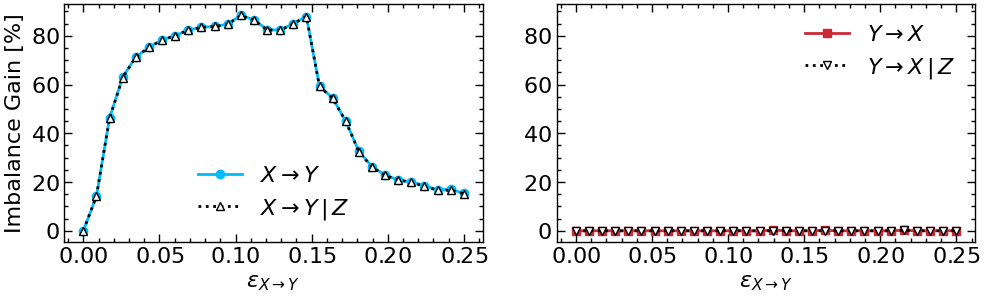

In [38]:
fig, ax = plt.subplots(1,2,figsize=(10,3))
fig.tight_layout() 
# X->Y
#ax[0].errorbar(epsilons, IGs_X_to_Y, errors_X_to_Y, fmt='.', markersize=0.1, color=colors[0], capsize=3.5, elinewidth=1.5, capthick=1)
ax[0].plot(epsilons, IGs_X_to_Y, 'o-', color=colors[0], alpha=1, label="$X\\rightarrow Y$", markeredgewidth=1, markeredgecolor=colors[0])
#ax[0].errorbar(epsilons, IGs_X_to_Y_cond, errors_X_to_Y_cond, fmt='.', markersize=0.1, color=colors[2], capsize=3.5, elinewidth=1.5, capthick=1)
ax[0].plot(epsilons, IGs_X_to_Y_cond, ':^', color="black", alpha=1, label="$X\\rightarrow Y \,|\, Z$", markerfacecolor='white', markeredgewidth=1, markeredgecolor="black")
# Y->X
#ax[1].errorbar(epsilons, IGs_Y_to_X, errors_Y_to_X, fmt='.', markersize=0.1, color=colors[1], capsize=3.5, elinewidth=1.5, capthick=1)
ax[1].plot(epsilons, IGs_Y_to_X, 's-', color=colors[1], label="$Y\\rightarrow X$", markeredgewidth=1, markeredgecolor=colors[1])
#ax[1].errorbar(epsilons, IGs_Y_to_X_cond, errors_Y_to_X_cond, fmt='.', markersize=0.1, color=colors[3], capsize=3.5, elinewidth=1.5, capthick=1)
ax[1].plot(epsilons, IGs_Y_to_X_cond, ':v', color="black", label="$Y\\rightarrow X \,|\, Z$", markerfacecolor='white', markeredgewidth=1, markeredgecolor="black")
# set labels
ax[0].set(xlabel="$\\varepsilon_{X\\rightarrow Y}$", ylabel="Imbalance Gain [%]")
ymin, ymax = ax[0].get_ylim()
ax[1].set(xlabel="$\\varepsilon_{X\\rightarrow Y}$", ylim=[ymin,ymax])
ax[0].legend()
ax[1].legend()
plt.savefig("./figures/rosslers_Zuncoupled_allcoords.pdf", dpi=300)
plt.show()

### Indirect

In [39]:
case = "indirect"

In [40]:
# with conditioning
IGs_X_to_Y_cond = np.zeros(len(epsilons))
errors_X_to_Y_cond = np.zeros(len(epsilons))
IGs_Y_to_X_cond = np.zeros(len(epsilons))
errors_Y_to_X_cond = np.zeros(len(epsilons))

# without conditioning
imbs_X_to_Y_nocond = np.zeros((len(seeds), len(epsilons), len(alphas_X)))
imbs_Y_to_X_nocond = np.zeros((len(seeds), len(epsilons), len(alphas_Y)))

for ieps, eps in tqdm(enumerate(epsilons)):
    imbs_X_to_X = np.zeros((len(seeds), len(alphas_Z)))
    imbs_Y_to_Y = np.zeros((len(seeds), len(alphas_Z)))
    imbs_X_to_Y = np.zeros((len(seeds), len(alphas_X)*len(alphas_Z)))
    imbs_Y_to_X = np.zeros((len(seeds), len(alphas_Y)*len(alphas_Z)))
    for iseed, seed in enumerate(seeds):
        # X->Y
        _, _, _, imbs_X_to_Y_nocond[iseed, ieps], imbs_Y_to_Y[iseed], imbs_X_to_Y[iseed] = pickle.load(
            open(f"./pickles/rossler_{case}/XtoY_seed{iseed}_ieps{ieps}.p","rb")
        )
        # Y->X
        _, _, _, imbs_Y_to_X_nocond[iseed, ieps], imbs_X_to_X[iseed], imbs_Y_to_X[iseed] = pickle.load(
            open(f"./pickles/rossler_{case}/YtoX_seed{iseed}_ieps{ieps}.p","rb")
        )

    IGs_X_to_Y_cond[ieps], errors_Y_to_X_cond[ieps] = compute_IGs_cond(
        imbs_Y_to_Y, imbs_X_to_Y, alphas_cause=alphas_X, alphas_cond=alphas_Z
    )
    IGs_Y_to_X_cond[ieps], errors_X_to_Y_cond[ieps] = compute_IGs_cond(
        imbs_X_to_X, imbs_Y_to_X, alphas_cause=alphas_Y, alphas_cond=alphas_Z
    )

IGs_X_to_Y, errors_X_to_Y = compute_IGs(imbs_X_to_Y_nocond)
IGs_Y_to_X, errors_Y_to_X = compute_IGs(imbs_Y_to_X_nocond)

0it [00:00, ?it/s]

30it [00:01, 15.23it/s]


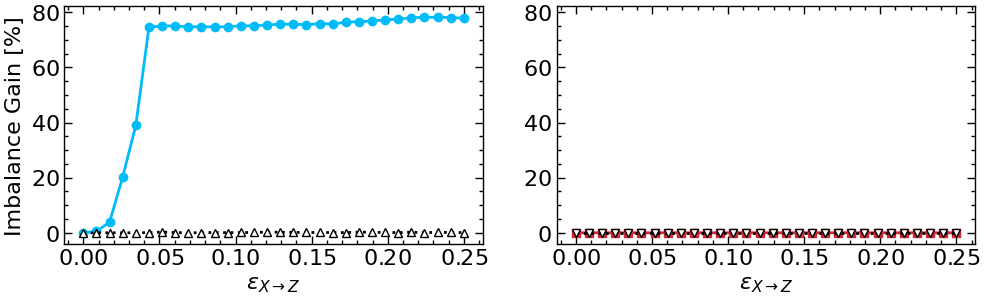

In [41]:
fig, ax = plt.subplots(1,2,figsize=(10,3))
fig.tight_layout() 
# X->Y
#ax[0].errorbar(epsilons, IGs_X_to_Y, errors_X_to_Y, fmt='.', markersize=0.1, color=colors[0], capsize=3.5, elinewidth=1.5, capthick=1)
ax[0].plot(epsilons, IGs_X_to_Y, 'o-', color=colors[0], alpha=1, label="$X\\rightarrow Y$", markeredgewidth=1, markeredgecolor=colors[0])
#ax[0].errorbar(epsilons, IGs_X_to_Y_cond, errors_X_to_Y_cond, fmt='.', markersize=0.1, color=colors[2], capsize=3.5, elinewidth=1.5, capthick=1)
ax[0].plot(epsilons, IGs_X_to_Y_cond, ':^', color="black", alpha=1, label="$X\\rightarrow Y \,|\, Z$", markerfacecolor='white', markeredgewidth=1, markeredgecolor="black")
# Y->X
#ax[1].errorbar(epsilons, IGs_Y_to_X, errors_Y_to_X, fmt='.', markersize=0.1, color=colors[1], capsize=3.5, elinewidth=1.5, capthick=1)
ax[1].plot(epsilons, IGs_Y_to_X, 's-', color=colors[1], label="$Y\\rightarrow X$", markeredgewidth=1, markeredgecolor=colors[1])
#ax[1].errorbar(epsilons, IGs_Y_to_X_cond, errors_Y_to_X_cond, fmt='.', markersize=0.1, color=colors[3], capsize=3.5, elinewidth=1.5, capthick=1)
ax[1].plot(epsilons, IGs_Y_to_X_cond, ':v', color="black", label="$Y\\rightarrow X \,|\, Z$", markerfacecolor='white', markeredgewidth=1, markeredgecolor="black")
# set labels
ax[0].set(xlabel="$\\varepsilon_{X\\rightarrow Z}$", ylabel="Imbalance Gain [%]")
ymin, ymax = ax[0].get_ylim()
ax[1].set(xlabel="$\\varepsilon_{X\\rightarrow Z}$", ylim=[ymin,ymax])
#ax[0].legend()
#ax[1].legend()
plt.savefig("./figures/rosslers_indirect_allcoords.pdf", dpi=300)
plt.show()

### Confounder

In [42]:
case = "confounder"

In [43]:
# with conditioning
IGs_X_to_Y_cond = np.zeros(len(epsilons))
errors_X_to_Y_cond = np.zeros(len(epsilons))
IGs_Y_to_X_cond = np.zeros(len(epsilons))
errors_Y_to_X_cond = np.zeros(len(epsilons))

# without conditioning
imbs_X_to_Y_nocond = np.zeros((len(seeds), len(epsilons), len(alphas_X)))
imbs_Y_to_X_nocond = np.zeros((len(seeds), len(epsilons), len(alphas_Y)))

for ieps, eps in tqdm(enumerate(epsilons)):
    imbs_X_to_X = np.zeros((len(seeds), len(alphas_Z)))
    imbs_Y_to_Y = np.zeros((len(seeds), len(alphas_Z)))
    imbs_X_to_Y = np.zeros((len(seeds), len(alphas_X)*len(alphas_Z)))
    imbs_Y_to_X = np.zeros((len(seeds), len(alphas_Y)*len(alphas_Z)))
    for iseed, seed in enumerate(seeds):
        # X->Y
        _, _, _, imbs_X_to_Y_nocond[iseed, ieps], imbs_Y_to_Y[iseed], imbs_X_to_Y[iseed] = pickle.load(
            open(f"./pickles/rossler_{case}/XtoY_seed{iseed}_ieps{ieps}.p","rb")
        )
        # Y->X
        _, _, _, imbs_Y_to_X_nocond[iseed, ieps], imbs_X_to_X[iseed], imbs_Y_to_X[iseed] = pickle.load(
            open(f"./pickles/rossler_{case}/YtoX_seed{iseed}_ieps{ieps}.p","rb")
        )

    IGs_X_to_Y_cond[ieps], errors_Y_to_X_cond[ieps] = compute_IGs_cond(
        imbs_Y_to_Y, imbs_X_to_Y, alphas_cause=alphas_X, alphas_cond=alphas_Z
    )
    IGs_Y_to_X_cond[ieps], errors_X_to_Y_cond[ieps] = compute_IGs_cond(
        imbs_X_to_X, imbs_Y_to_X, alphas_cause=alphas_Y, alphas_cond=alphas_Z
    )

IGs_X_to_Y, errors_X_to_Y = compute_IGs(imbs_X_to_Y_nocond)
IGs_Y_to_X, errors_Y_to_X = compute_IGs(imbs_Y_to_X_nocond)

30it [00:01, 15.73it/s]


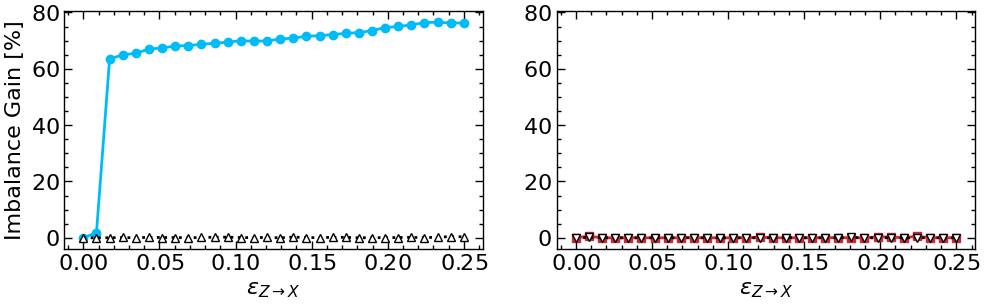

In [44]:
fig, ax = plt.subplots(1,2,figsize=(10,3))
fig.tight_layout() 
# X->Y
#ax[0].errorbar(epsilons, IGs_X_to_Y, errors_X_to_Y, fmt='.', markersize=0.1, color=colors[0], capsize=3.5, elinewidth=1.5, capthick=1)
ax[0].plot(epsilons, IGs_X_to_Y, 'o-', color=colors[0], alpha=1, label="$X\\rightarrow Y$", markeredgewidth=1, markeredgecolor=colors[0])
#ax[0].errorbar(epsilons, IGs_X_to_Y_cond, errors_X_to_Y_cond, fmt='.', markersize=0.1, color=colors[2], capsize=3.5, elinewidth=1.5, capthick=1)
ax[0].plot(epsilons, IGs_X_to_Y_cond, ':^', color="black", alpha=1, label="$X\\rightarrow Y \,|\, Z$", markerfacecolor='white', markeredgewidth=1, markeredgecolor="black")
# Y->X
#ax[1].errorbar(epsilons, IGs_Y_to_X, errors_Y_to_X, fmt='.', markersize=0.1, color=colors[1], capsize=3.5, elinewidth=1.5, capthick=1)
ax[1].plot(epsilons, IGs_Y_to_X, 's-', color=colors[1], label="$Y\\rightarrow X$", markeredgewidth=1, markeredgecolor=colors[1])
#ax[1].errorbar(epsilons, IGs_Y_to_X_cond, errors_Y_to_X_cond, fmt='.', markersize=0.1, color=colors[3], capsize=3.5, elinewidth=1.5, capthick=1)
ax[1].plot(epsilons, IGs_Y_to_X_cond, ':v', color="black", label="$Y\\rightarrow X \,|\, Z$", markerfacecolor='white', markeredgewidth=1, markeredgecolor="black")
# set labels
ax[0].set(xlabel="$\\varepsilon_{Z\\rightarrow X}$", ylabel="Imbalance Gain [%]")
ymin, ymax = ax[0].get_ylim()
ax[1].set(xlabel="$\\varepsilon_{Z\\rightarrow X}$", ylim=[ymin,ymax])
#ax[0].legend()
#ax[1].legend()
plt.savefig("./figures/rosslers_confounder_allcoords.pdf", dpi=300)
plt.show()